# Tugas Besar 1 IF3270 Pembelajaran Mesin
## Feedforward Neural Network

**Nama Anggota:**
- 13523075 — Muhammad Dicky Isra
- 13523114 — Guntara Hambali
- 13523119 — Reza Ahmad Syarif

**Kelas:** K02

## Import Libraries

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os

if './src' not in sys.path:
    sys.path.append('./src')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier

from ffnn.models import Sequential
from ffnn.layers import Dense
from ffnn.regularizer import l1, l2
from ffnn.optimizers import Adam, SGD

from ffnn.activations import Activation
from ffnn.normalizers import RMSNormalization

print("Berhasil import")

Berhasil import


## Simple EDA

In [5]:
df = pd.read_csv('datasetml_2026.csv')

print("Dataset Shape: ", df.shape)
print("Dataset Columns: ", df.columns)
print("Dataset Head: ")
df.head()

Dataset Shape:  (10000, 12)
Dataset Columns:  Index(['cgpa', 'backlogs', 'college_tier', 'country',
       'university_ranking_band', 'internship_count', 'aptitude_score',
       'communication_score', 'specialization', 'industry',
       'internship_quality_score', 'placement_status'],
      dtype='object')
Dataset Head: 


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [7]:
df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


In [8]:
TARGET_COL = 'placement_status'

CAT_COLS = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + [TARGET_COL]]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

Categorical: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


## Encoding Fitur Kategorik

In [9]:
df['placement_status'] = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

college_mapping = {'Tier 3': 1, 'Tier 2': 2, 'Tier 1': 3}
ranking_mapping = {'300+': 1, '100-300': 2, 'Top 100': 3}
df['college_tier'] = df['college_tier'].map(college_mapping)
df['university_ranking_band'] = df['university_ranking_band'].map(ranking_mapping)

df = pd.get_dummies(df, columns=['country', 'specialization', 'industry'], drop_first=False)
df = df.astype(np.float64)

X = df.drop([TARGET_COL], axis=1).values
y = df[TARGET_COL].values

## Train\-Validation Split and Feature Scaling

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Shape X_train:", X_train_scaled.shape)
print("Shape X_val:", X_val_scaled.shape)

Shape X_train: (8000, 24)
Shape X_val: (2000, 24)


## Helper Function

In [11]:
import math
# Fungsi buat plot learning curve
def plot_learning_curves(histories_dict, title="Perbandingan Learning Curve", y_label="Loss"):
    n_plots = len(histories_dict)
    n_cols = min(n_plots, 3)
    n_rows = math.ceil(n_plots / 3)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    if n_plots > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    fig.suptitle(title, fontsize=16)
    for i, (name, history) in enumerate(histories_dict.items()):
        ax = axes[i]
        ax.plot(history['training_loss'], label='Train Loss', color='blue')
        if 'validation_loss' in history and len(history['validation_loss']) > 0:
            ax.plot(history['validation_loss'], label='Val Loss', color='orange')
        ax.set_title(name)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(y_label)
        ax.legend()
        ax.grid(True)
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

# Fungsi buat plot distribusi bobot sama gradien
def plot_distributions(models_dict, layer_idx=0, title=None):
    if title is None:
        title = f"Distribusi Bobot dan Gradien di Layer {layer_idx}"
    jumlah_skenario = len(models_dict)
    fig, axes = plt.subplots(jumlah_skenario, 2, figsize=(14, 4 * jumlah_skenario))
    if jumlah_skenario == 1: axes = [axes]
    fig.suptitle(title, fontsize=16)
    for i, (name, model) in enumerate(models_dict.items()):
        layer_uji = model.layers[layer_idx]
        weights_flat = layer_uji.weights.flatten()
        gradients_flat = layer_uji.dW.flatten()
        axes[i][0].hist(weights_flat, bins=30, color='purple', alpha=0.7)
        axes[i][0].set_title(f'Distribusi Bobot ({name})')
        axes[i][0].set_ylabel('Frekuensi')
        axes[i][1].hist(gradients_flat, bins=30, color='green', alpha=0.7)
        axes[i][1].set_title(f'Distribusi Gradien dW ({name})')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Fungsi hasil prediksi
def evaluate_metrics(predictions_dict, y_true, title="Hasil Evaluasi Prediksi"):
    print(title)
    y_true_flat = y_true.flatten() if y_true.ndim > 1 else y_true
    for name, y_pred in predictions_dict.items():
        acc = accuracy_score(y_true_flat, y_pred)
        prec = precision_score(y_true_flat, y_pred, zero_division=0)
        rec = recall_score(y_true_flat, y_pred, zero_division=0)
        f1 = f1_score(y_true_flat, y_pred, zero_division=0)
        print(f"\n[{name}]:")
        print(f"- Accuracy  : {acc:.4f}")
        print(f"- Precision : {prec:.4f}")
        print(f"- Recall    : {rec:.4f}")
        print(f"- F1-Score  : {f1:.4f}")

## Eksperimen Pengaruh Depth dan Width

Eksperimen Variasi Depth
Training Depth_2 (2 Layer, 16 Neuron)
Training Depth_3 (3 Layer, 16 Neuron)
Training Depth_4 (4 Layer, 16 Neuron)


d:\Kuliah\Tubes\Machine Learning\ml-tubes-1\src\ffnn\activations.py:21: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))



Eksperimen Variasi Width
Training Width_4 (1 Layer, 4 Neuron)
Training Width_16 (1 Layer, 16 Neuron)
Training Width_64 (1 Layer, 64 Neuron)


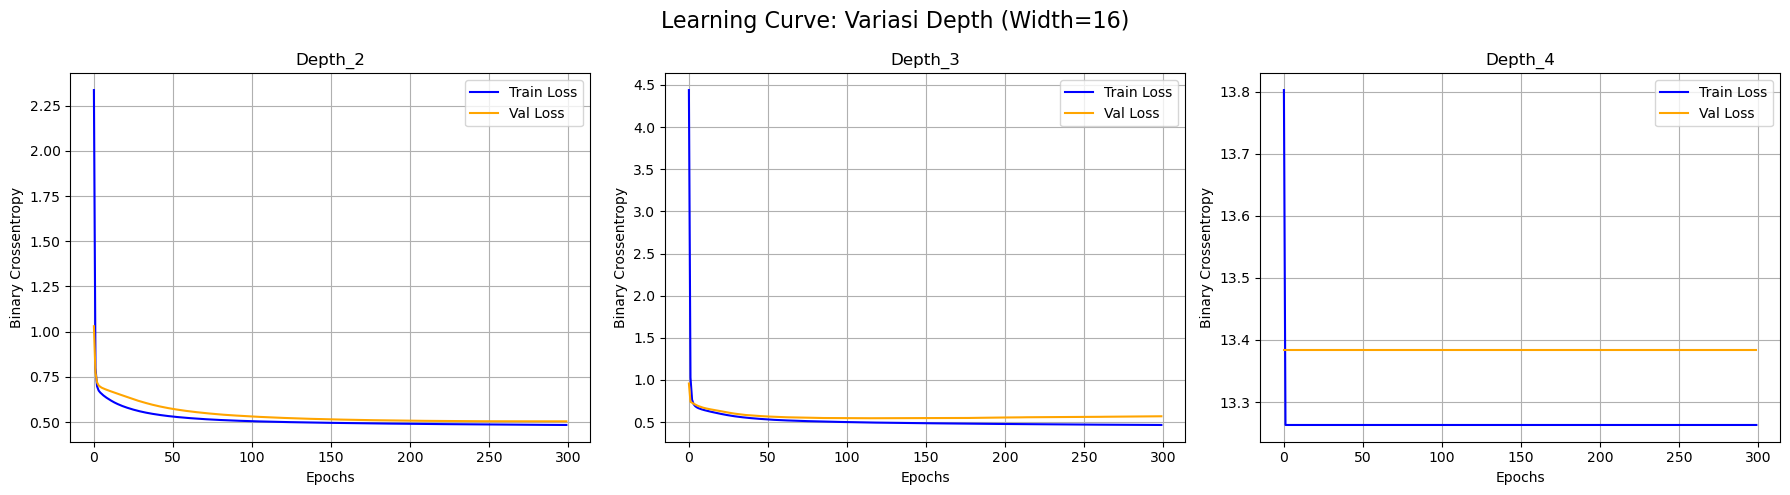

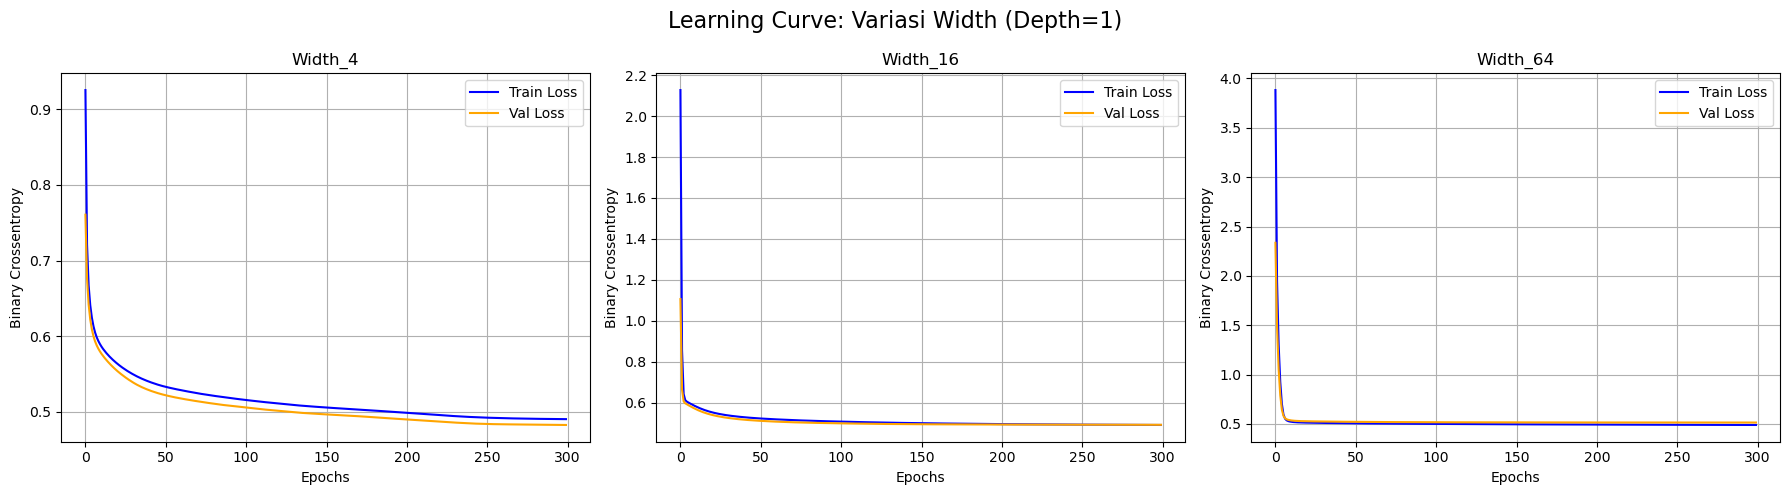

Evaluasi Prediksi: Variasi Depth

[Depth_2]:
- Accuracy  : 0.7525
- Precision : 0.7626
- Recall    : 0.8653
- F1-Score  : 0.8107

[Depth_3]:
- Accuracy  : 0.7390
- Precision : 0.7513
- Recall    : 0.8580
- F1-Score  : 0.8011

[Depth_4]:
- Accuracy  : 0.6125
- Precision : 0.6125
- Recall    : 1.0000
- F1-Score  : 0.7597
Evaluasi Prediksi: Variasi Width

[Width_4]:
- Accuracy  : 0.7625
- Precision : 0.7741
- Recall    : 0.8645
- F1-Score  : 0.8168

[Width_16]:
- Accuracy  : 0.7570
- Precision : 0.7622
- Recall    : 0.8767
- F1-Score  : 0.8155

[Width_64]:
- Accuracy  : 0.7510
- Precision : 0.7461
- Recall    : 0.8996
- F1-Score  : 0.8157


In [12]:
input_dim = X_train_scaled.shape[1]
epochs = 300
batch_size = 32
lr = 0.01
histories_depth = {}
predictions_depth = {}
histories_width = {}
predictions_width = {}

# Variasi Depth
print("Eksperimen Variasi Depth")
depths = [2, 3, 4]
for d in depths:
    name = f"Depth_{d}"
    print(f"Training {name} ({d} Layer, 16 Neuron)")
    model = Sequential()
    model.add(Dense(n_neuron=16, input_dim=input_dim, activation="relu", seed=42))
    for i in range(d-1):
        model.add(Dense(n_neuron=16, activation="relu", seed=42))
    model.add(Dense(n_neuron=1, activation="sigmoid", seed= 42))
    model.compile(loss="binary_crossentropy")

    histories_depth[name] = model.fit(
        x_train=X_train_scaled, 
        y_train=y_train, 
        x_val=X_val_scaled, 
        y_val=y_val,
        epochs=epochs, 
        batch_size=batch_size, 
        learning_rate=lr, 
        verbose=0
    )
    predictions_depth[name] = (model.predict(X_val_scaled) > 0.5).astype(int).flatten()

# Variasi Width
print("\nEksperimen Variasi Width")
widths = [4, 16, 64]
for w in widths:
    name = f"Width_{w}"
    print(f"Training {name} (1 Layer, {w} Neuron)")
    model = Sequential()
    model.add(Dense(n_neuron=w, input_dim=input_dim, activation="relu", seed=42))
    model.add(Dense(n_neuron=1, activation="sigmoid", seed= 42))
    model.compile(loss="binary_crossentropy")

    histories_width[name] = model.fit(
        x_train=X_train_scaled, 
        y_train=y_train, 
        x_val=X_val_scaled, 
        y_val=y_val,
        epochs=epochs, 
        batch_size=batch_size, 
        learning_rate=lr, 
        verbose=0
    )
    predictions_width[name] = (model.predict(X_val_scaled) > 0.5).astype(int).flatten()

plot_learning_curves(histories_depth, title="Learning Curve: Variasi Depth (Width=16)", y_label="Binary Crossentropy")
plot_learning_curves(histories_width, title="Learning Curve: Variasi Width (Depth=1)", y_label="Binary Crossentropy")
evaluate_metrics(predictions_depth, y_val, title="Evaluasi Prediksi: Variasi Depth")
evaluate_metrics(predictions_width, y_val, title="Evaluasi Prediksi: Variasi Width")

## 
Eksperimen Pengaruh Fungsi Aktivasi Hidden Layer

Eksperimen Pengaruh Fungsi Aktivasi Hidden Layer
Training dengan aktivasi: LINEAR
Training dengan aktivasi: SIGMOID
Training dengan aktivasi: RELU
Training dengan aktivasi: TANH
Training dengan aktivasi: SWISH
Training dengan aktivasi: LEAKY_RELU


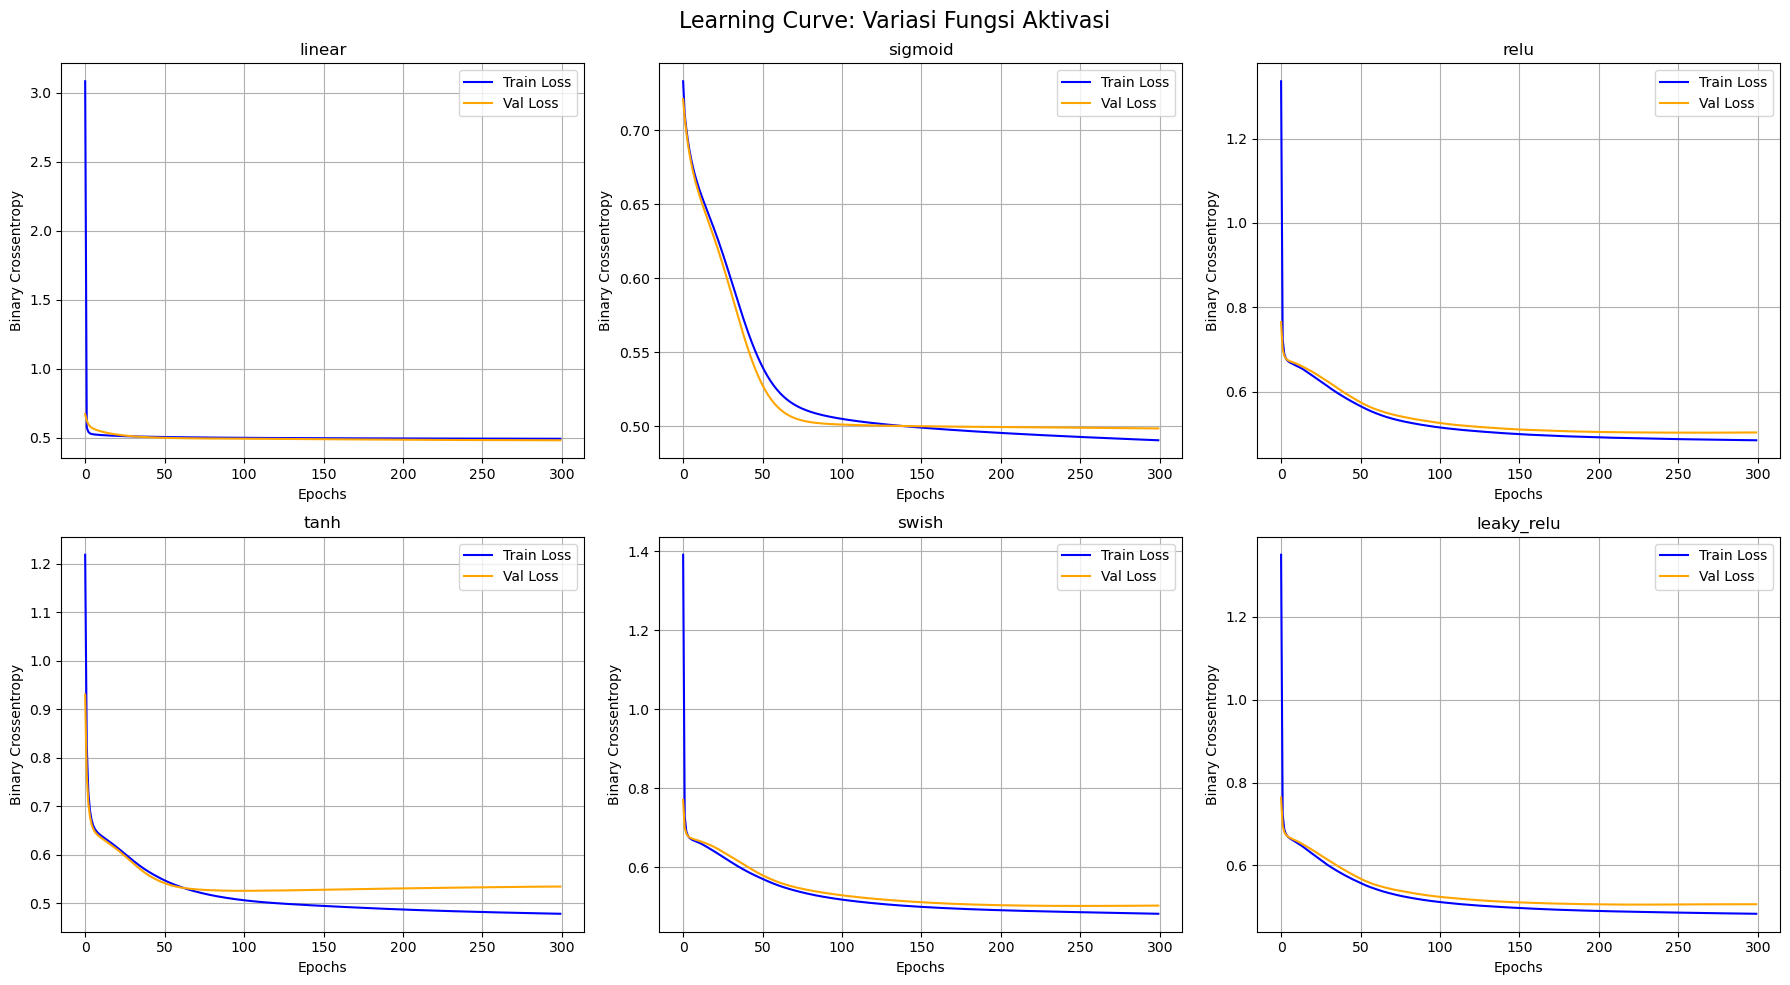

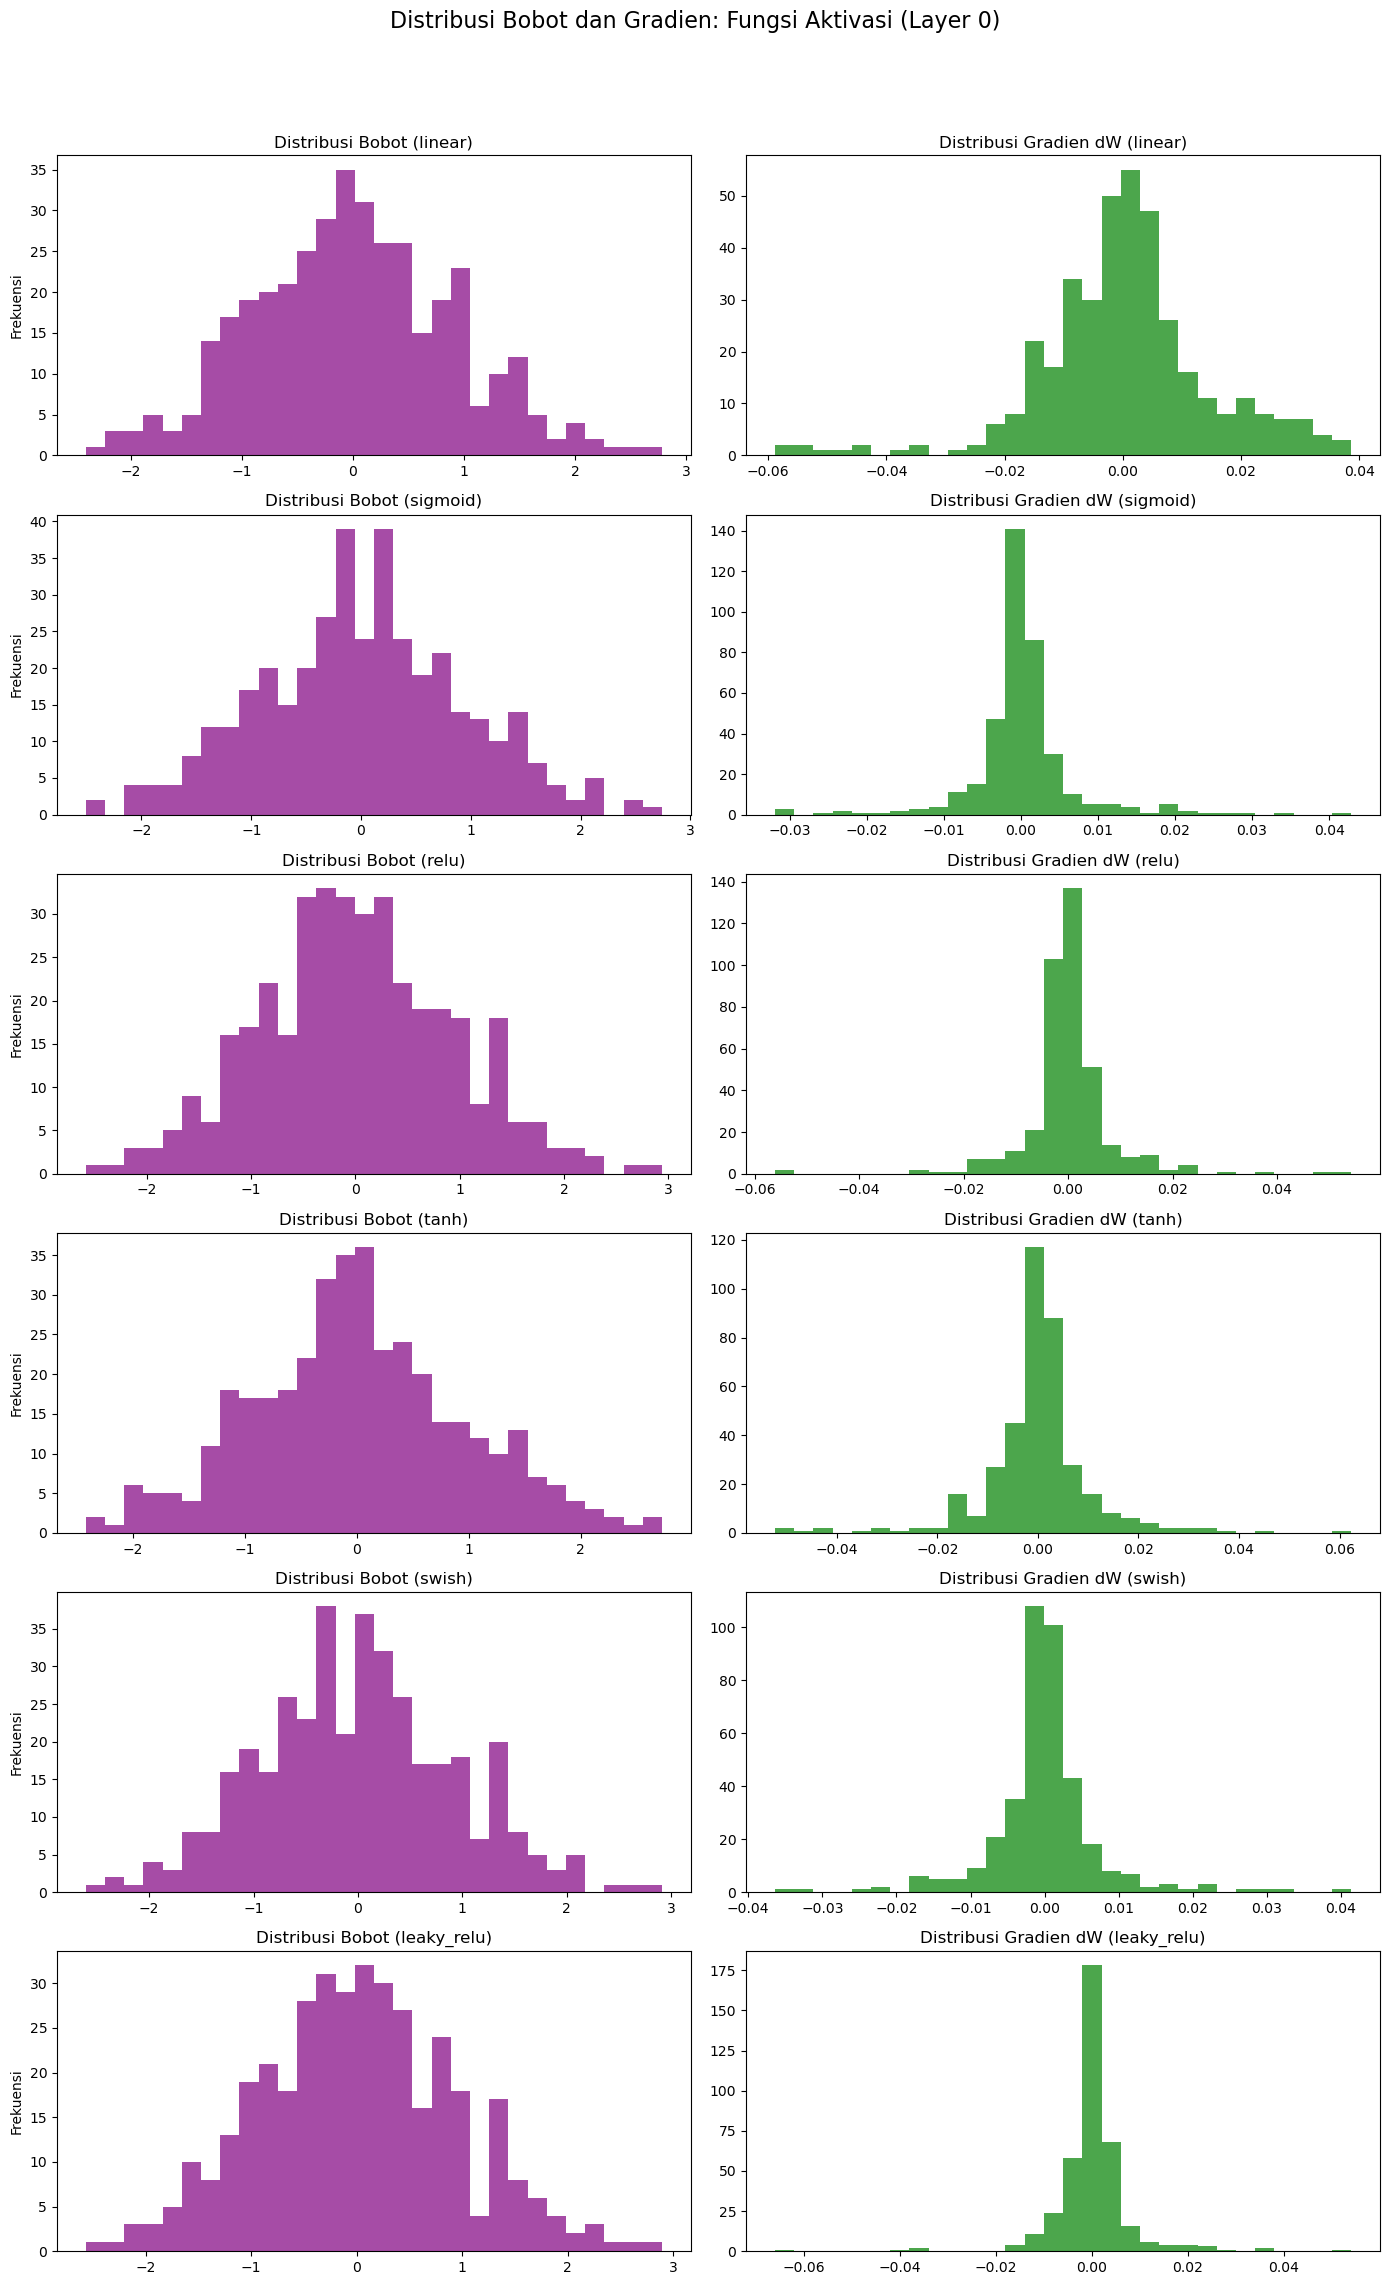

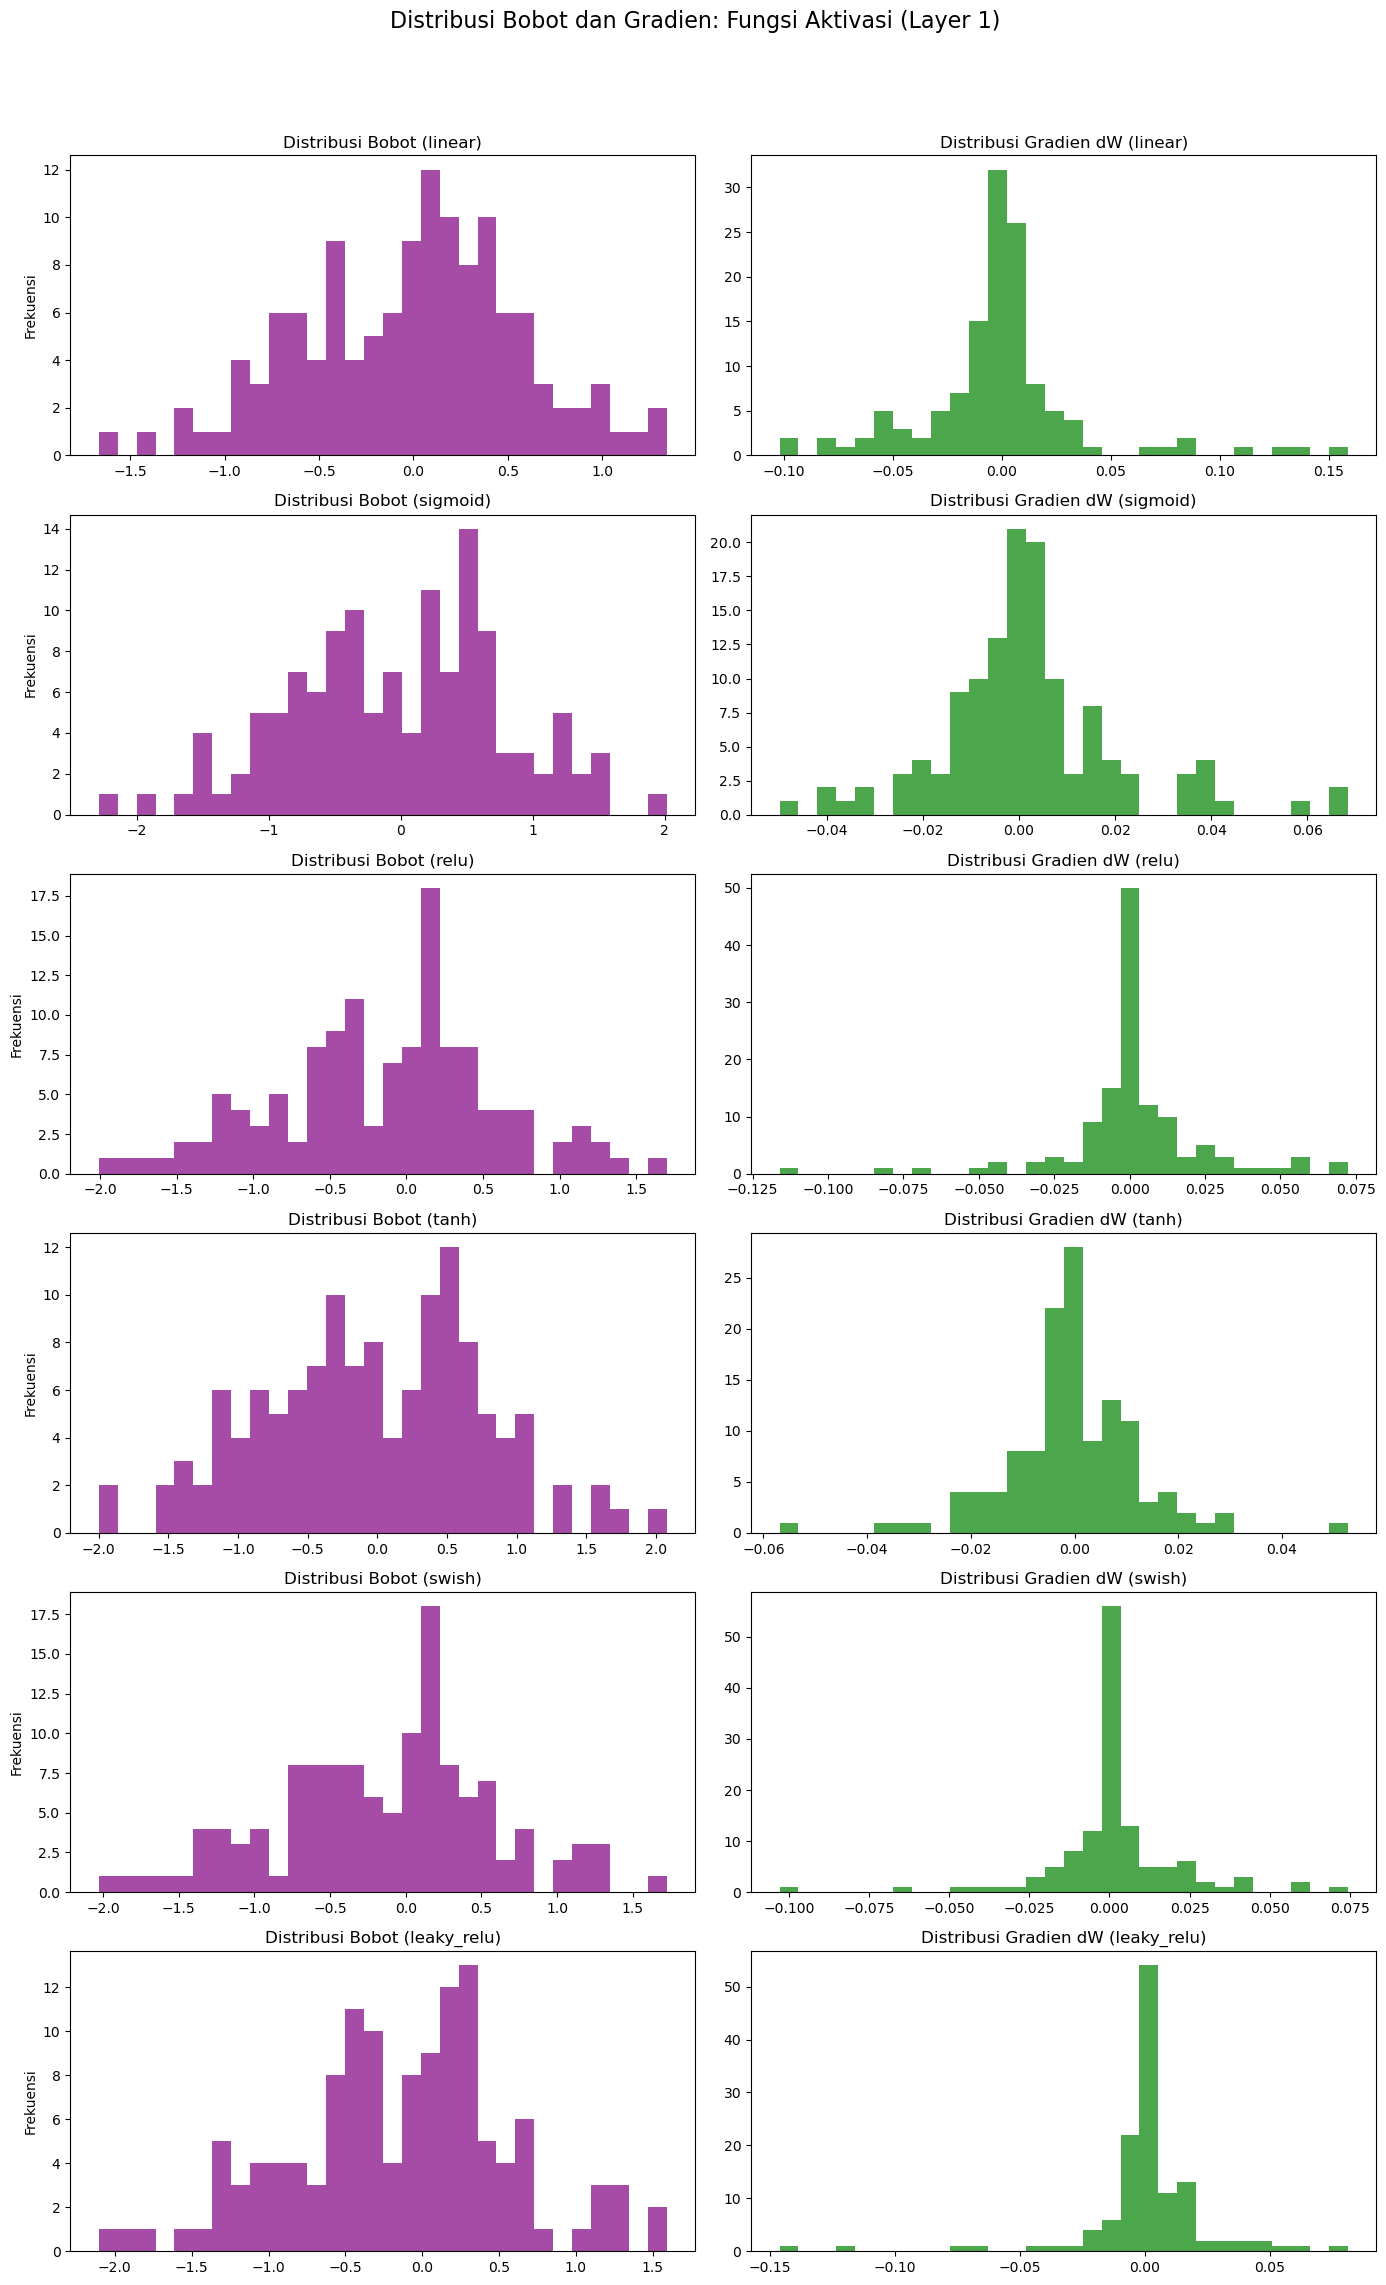

Evaluasi Prediksi: FUngsi Aktivasi

[linear]:
- Accuracy  : 0.7685
- Precision : 0.7729
- Recall    : 0.8808
- F1-Score  : 0.8233

[sigmoid]:
- Accuracy  : 0.7635
- Precision : 0.7793
- Recall    : 0.8563
- F1-Score  : 0.8160

[relu]:
- Accuracy  : 0.7605
- Precision : 0.7687
- Recall    : 0.8710
- F1-Score  : 0.8167

[tanh]:
- Accuracy  : 0.7440
- Precision : 0.7635
- Recall    : 0.8433
- F1-Score  : 0.8014

[swish]:
- Accuracy  : 0.7530
- Precision : 0.7613
- Recall    : 0.8694
- F1-Score  : 0.8117

[leaky_relu]:
- Accuracy  : 0.7560
- Precision : 0.7638
- Recall    : 0.8710
- F1-Score  : 0.8139


In [13]:
input_dim = X_train_scaled.shape[1]
epochs = 300
batch_size = 32
lr = 0.01
activations = ['linear', 'sigmoid', 'relu', 'tanh', 'swish', 'leaky_relu']
models_dict = {}
histories_act = {}
predictions_act = {}

print("Eksperimen Pengaruh Fungsi Aktivasi Hidden Layer")
for act in activations:
    print(f"Training dengan aktivasi: {act.upper()}")
    model = Sequential()
    model.add(Dense(n_neuron=16, input_dim=input_dim, activation=act, seed=42)) # Layer 0 jadi layer uji
    model.add(Dense(n_neuron=8, activation=act, seed=42))
    model.add(Dense(n_neuron=1, activation="sigmoid", seed=42))
    model.compile(loss="binary_crossentropy")
    
    histories_act[act] = model.fit(
        x_train=X_train_scaled, 
        y_train=y_train, 
        x_val=X_val_scaled, 
        y_val=y_val,
        epochs=epochs, 
        batch_size=batch_size, 
        learning_rate=lr, 
        verbose=0
    )
    predictions_act[act] = (model.predict(X_val_scaled) > 0.5).astype(int).flatten()
    models_dict[act] = model

plot_learning_curves(histories_act, title="Learning Curve: Variasi Fungsi Aktivasi", y_label="Binary Crossentropy")
plot_distributions(models_dict, layer_idx=0, title="Distribusi Bobot dan Gradien: Fungsi Aktivasi (Layer 0)")
plot_distributions(models_dict, layer_idx=1, title="Distribusi Bobot dan Gradien: Fungsi Aktivasi (Layer 1)")
evaluate_metrics(predictions_act, y_val, title="Evaluasi Prediksi: FUngsi Aktivasi")

## Eksperimen Pengaruh Learning Rate

Eksperimen Pengaruh Learning Rate
Training dengan Learning Rate: 0.5
Training dengan Learning Rate: 0.01
Training dengan Learning Rate: 0.0001


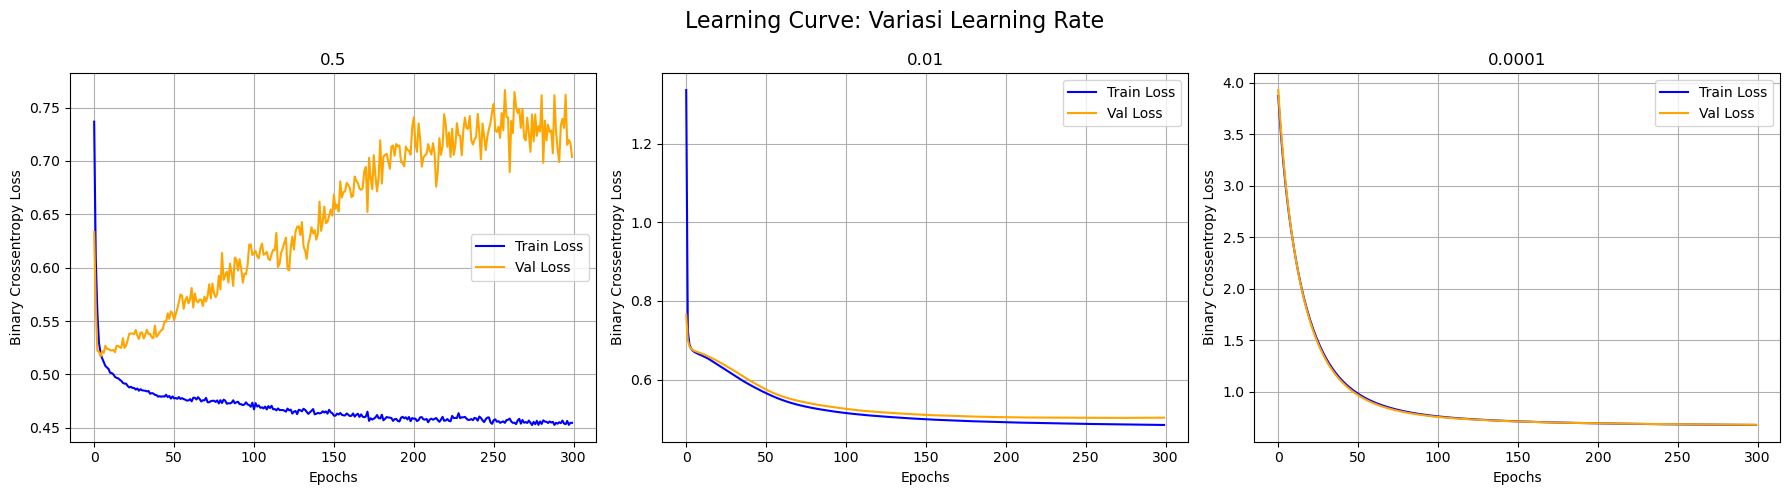

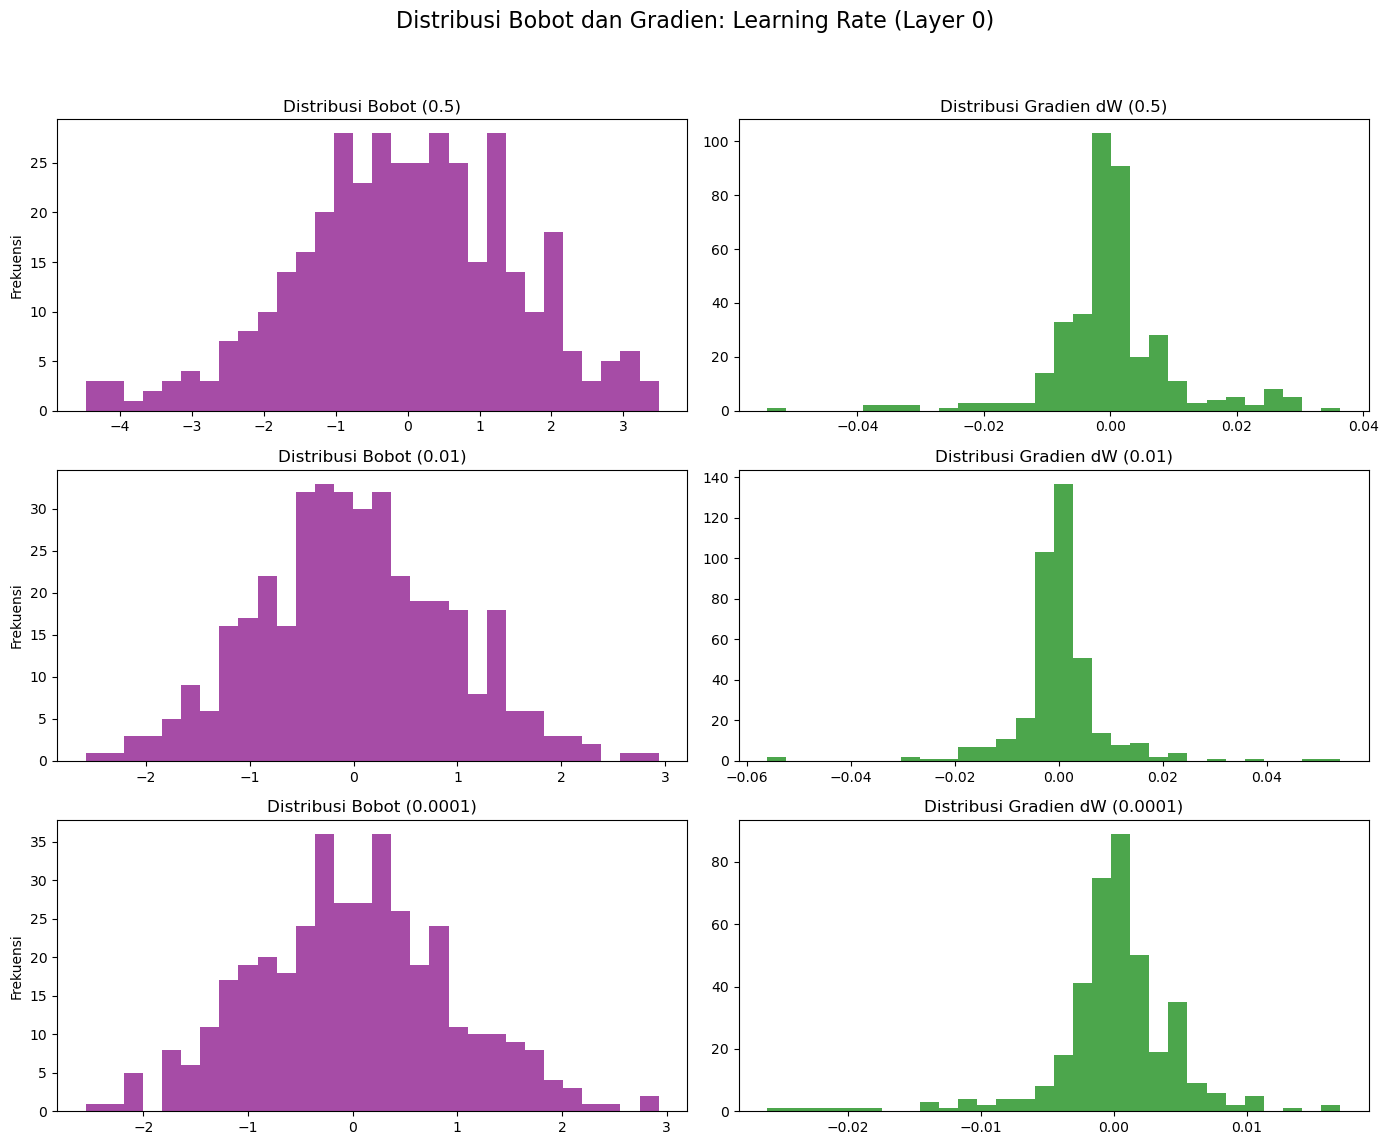

Evaluasi Prediksi: Learning Rate

[0.5]:
- Accuracy  : 0.7130
- Precision : 0.7033
- Recall    : 0.9192
- F1-Score  : 0.7969

[0.01]:
- Accuracy  : 0.7605
- Precision : 0.7687
- Recall    : 0.8710
- F1-Score  : 0.8167

[0.0001]:
- Accuracy  : 0.6025
- Precision : 0.6155
- Recall    : 0.9355
- F1-Score  : 0.7425


In [14]:
input_dim = X_train_scaled.shape[1] 
epochs = 300
batch_size = 32
learning_rates = [0.5, 0.01, 0.0001]
models_dict_lr = {}
histories_lr = {}
predictions_lr = {}

print("Eksperimen Pengaruh Learning Rate")
for lr in learning_rates:
    lr_str = str(lr)
    print(f"Training dengan Learning Rate: {lr_str}")
    model = Sequential()
    model.add(Dense(n_neuron=16, input_dim=input_dim, activation="relu", seed=42))
    model.add(Dense(n_neuron=8, activation="relu", seed=42))
    model.add(Dense(n_neuron=1, activation="sigmoid", seed=42))
    model.compile(loss="binary_crossentropy")
    
    histories_lr[lr_str] = model.fit(
        x_train=X_train_scaled, 
        y_train=y_train, 
        x_val=X_val_scaled, 
        y_val=y_val,
        epochs=epochs, 
        batch_size=batch_size, 
        learning_rate=lr, 
        verbose=0
    )
    predictions_lr[lr_str] = (model.predict(X_val_scaled) > 0.5).astype(int).flatten()
    models_dict_lr[lr_str] = model

plot_learning_curves(histories_lr, title="Learning Curve: Variasi Learning Rate", y_label="Binary Crossentropy Loss")
plot_distributions(models_dict_lr, layer_idx=0, title="Distribusi Bobot dan Gradien: Learning Rate (Layer 0)")
evaluate_metrics(predictions_lr, y_val, title="Evaluasi Prediksi: Learning Rate")

## Eksperimen Pengaruh Inisialisasi Bobot

Eksperimen Pengaruh Inisialisasi Bobot
Training dengan Inisialisasi: zeros
Training dengan Inisialisasi: random_uniform
Training dengan Inisialisasi: random_normal
Training dengan Inisialisasi: xavier
Training dengan Inisialisasi: he


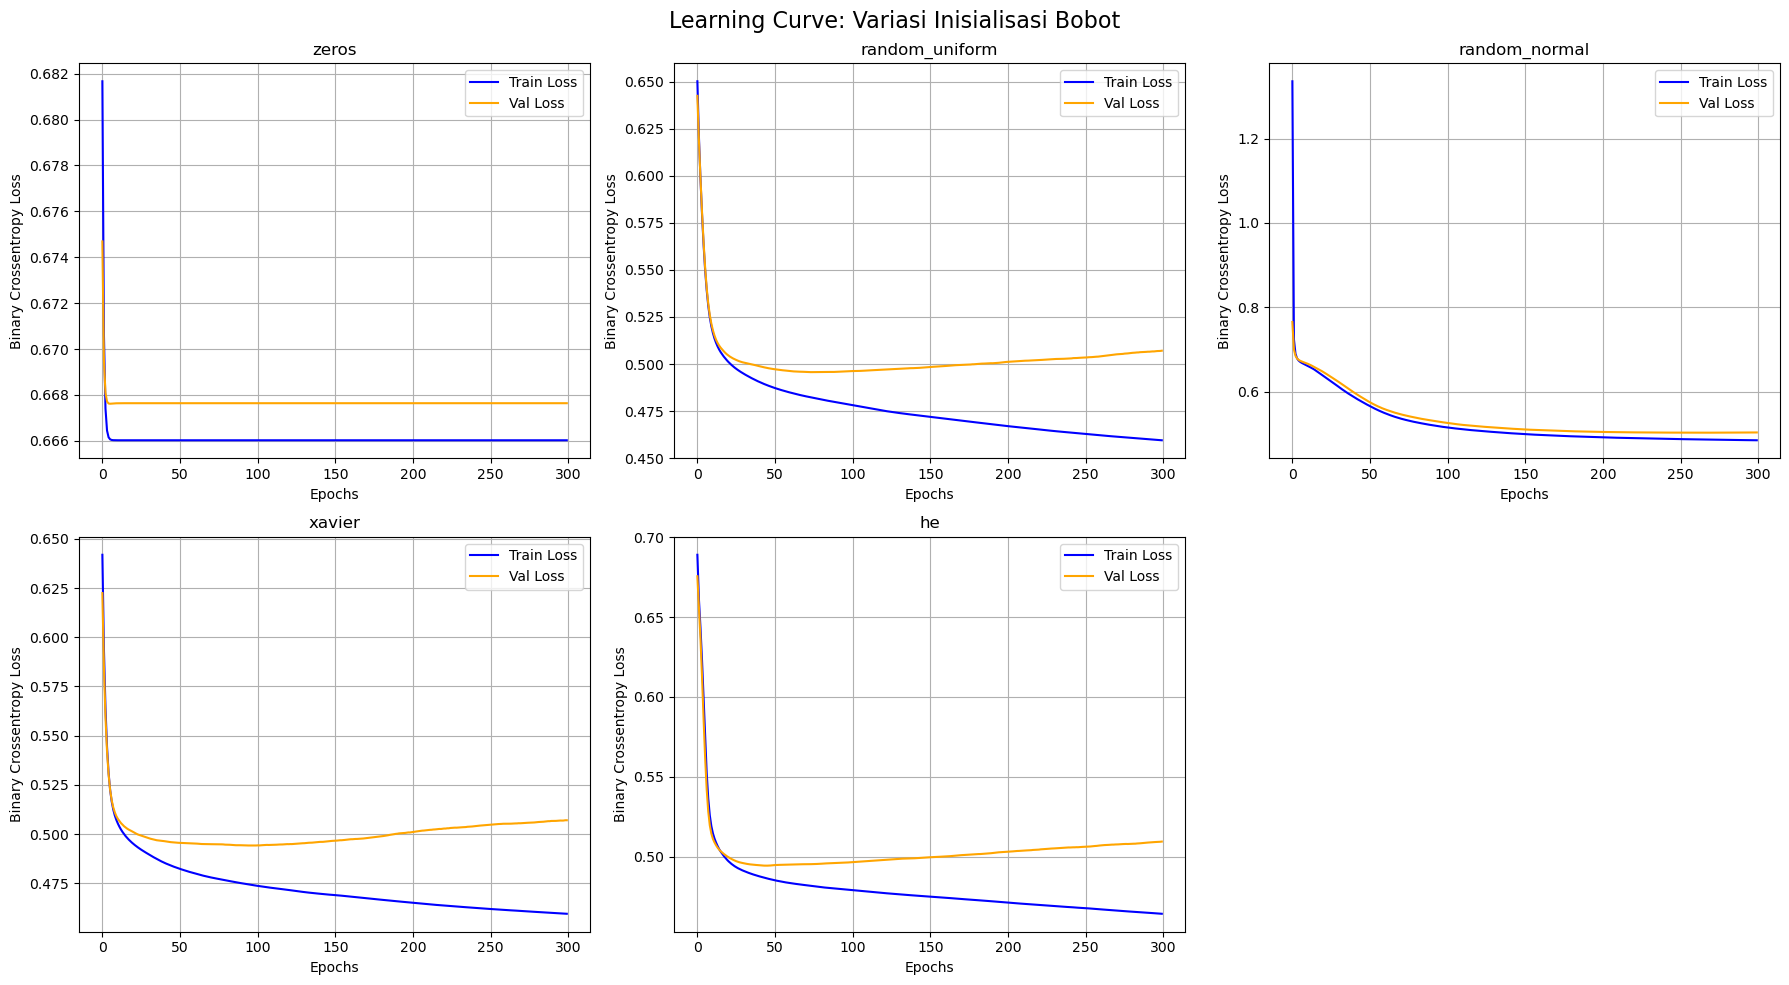

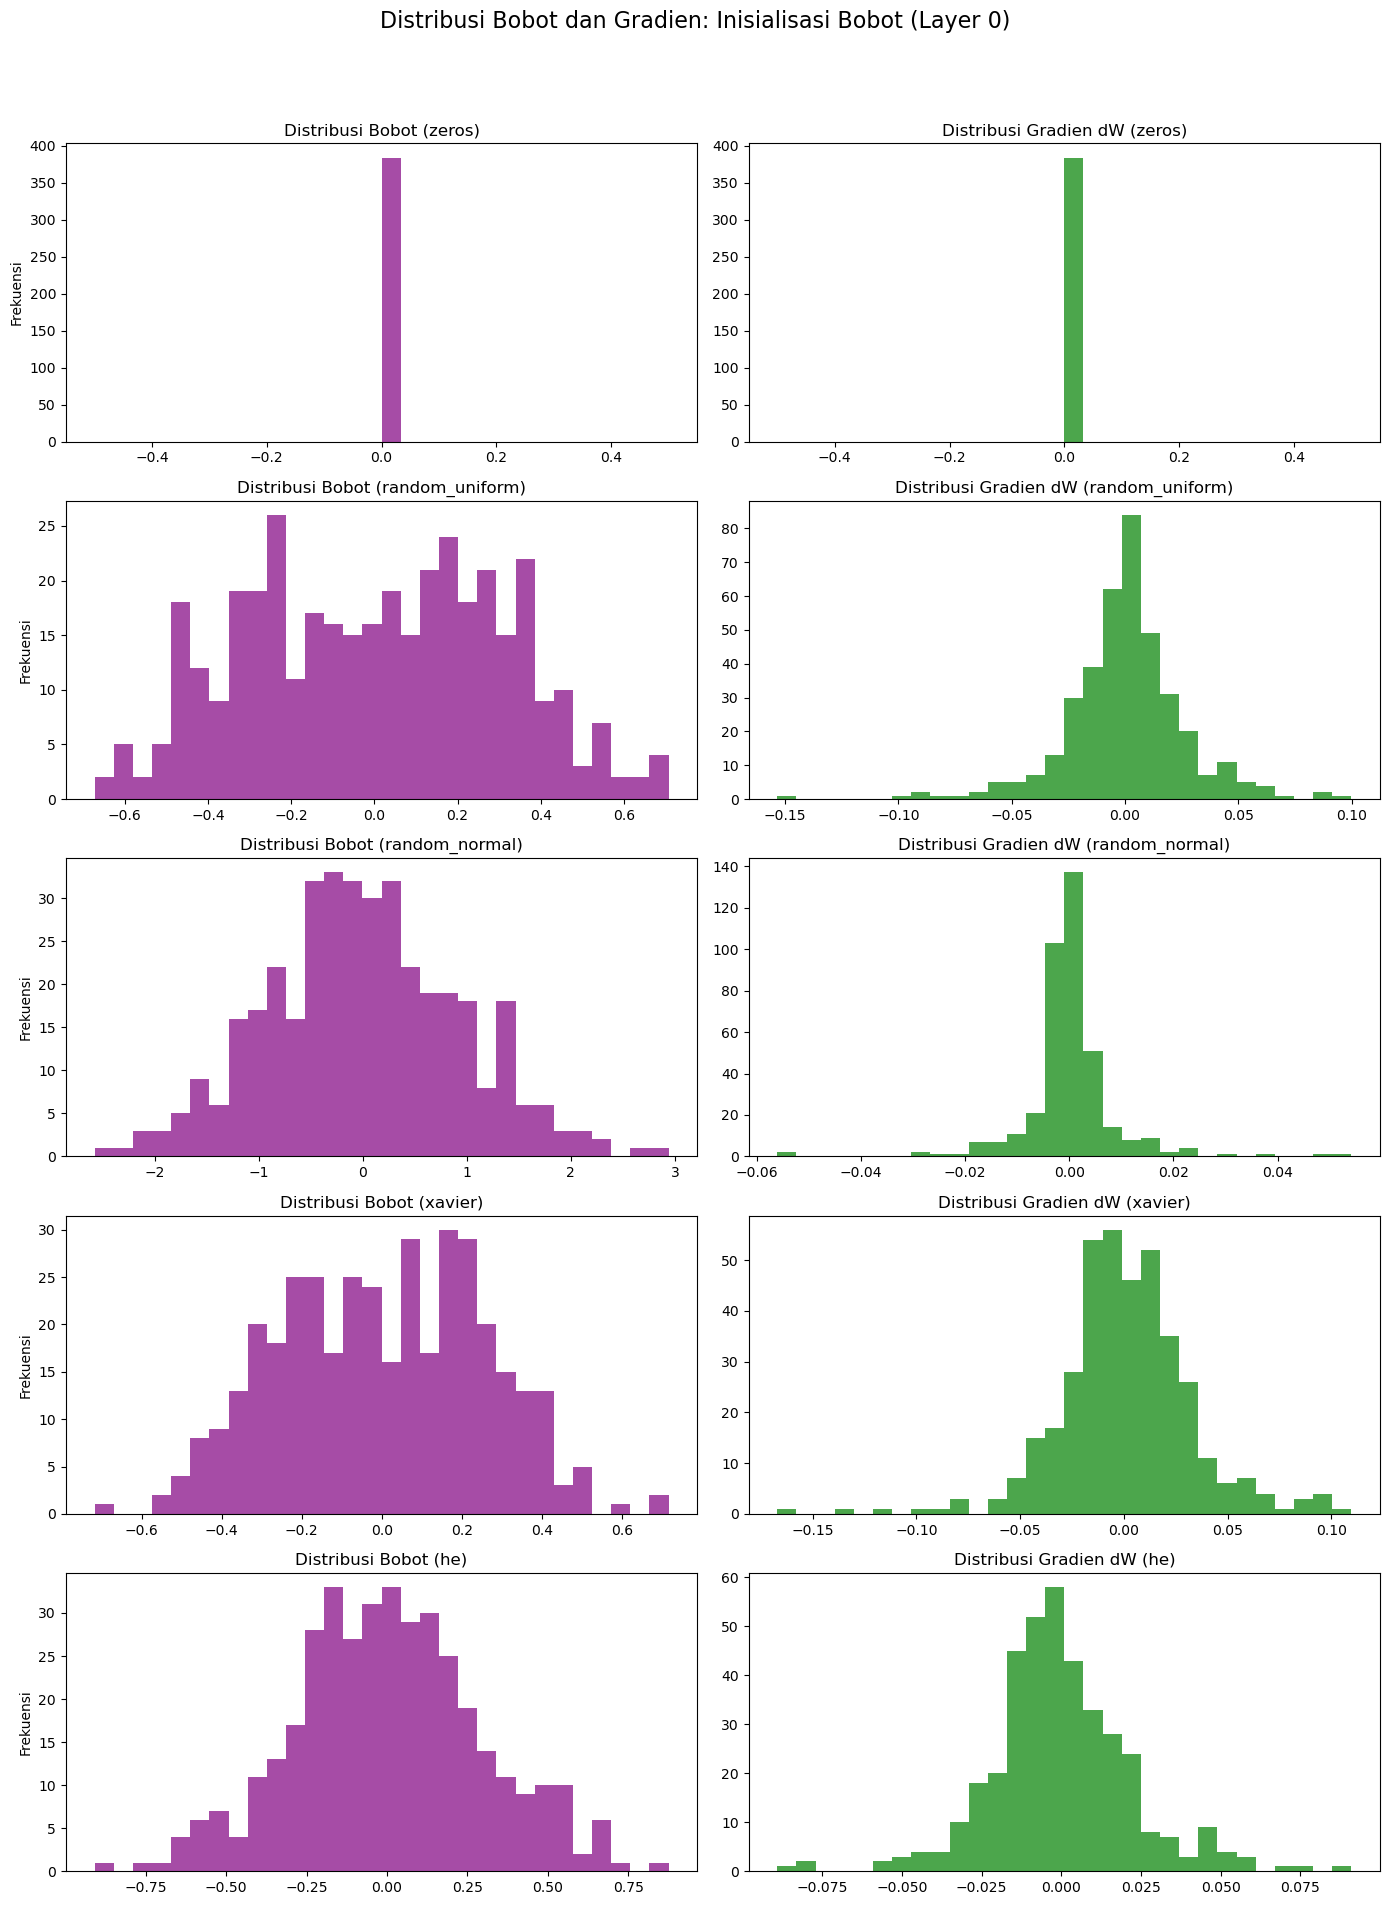

Evaluasi Prediksi: Inisialisasi Bobot

[zeros]:
- Accuracy  : 0.6125
- Precision : 0.6125
- Recall    : 1.0000
- F1-Score  : 0.7597

[random_uniform]:
- Accuracy  : 0.7415
- Precision : 0.7634
- Recall    : 0.8376
- F1-Score  : 0.7988

[random_normal]:
- Accuracy  : 0.7605
- Precision : 0.7687
- Recall    : 0.8710
- F1-Score  : 0.8167

[xavier]:
- Accuracy  : 0.7600
- Precision : 0.7761
- Recall    : 0.8547
- F1-Score  : 0.8135

[he]:
- Accuracy  : 0.7570
- Precision : 0.7731
- Recall    : 0.8539
- F1-Score  : 0.8115


In [15]:
input_dim = X_train_scaled.shape[1]
epochs = 300
batch_size = 32
lr = 0.01
initializers = ['zeros', 'random_uniform', 'random_normal', 'xavier', 'he']
models_dict_init = {}
histories_init = {}
predictions_init = {}

print("Eksperimen Pengaruh Inisialisasi Bobot")
for init in initializers:
    print(f"Training dengan Inisialisasi: {init}")
    model = Sequential()
    model.add(Dense(n_neuron=16, input_dim=input_dim, activation="relu", weight_initializer=init, seed=42))
    model.add(Dense(n_neuron=8, activation="relu", weight_initializer=init, seed=42))
    model.add(Dense(n_neuron=1, activation="sigmoid", weight_initializer=init, seed=42))
    model.compile(loss="binary_crossentropy")
    
    histories_init[init] = model.fit(
        x_train=X_train_scaled, 
        y_train=y_train, 
        x_val=X_val_scaled, 
        y_val=y_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        learning_rate=lr, 
        verbose=0
    )
    predictions_init[init] = (model.predict(X_val_scaled) > 0.5).astype(int).flatten()
    models_dict_init[init] = model

plot_learning_curves(histories_init, title="Learning Curve: Variasi Inisialisasi Bobot", y_label="Binary Crossentropy Loss")
plot_distributions(models_dict_init, layer_idx=0, title="Distribusi Bobot dan Gradien: Inisialisasi Bobot (Layer 0)")
evaluate_metrics(predictions_init, y_val, title="Evaluasi Prediksi: Inisialisasi Bobot")

## Eksperimen Pengaruh Regulariasi

Eksperimen Pengaruh Regularisasi
Training Model: Tanpa Regularisasi
Training Model: L1 Regularisasi
Training Model: L2 Regularisasi


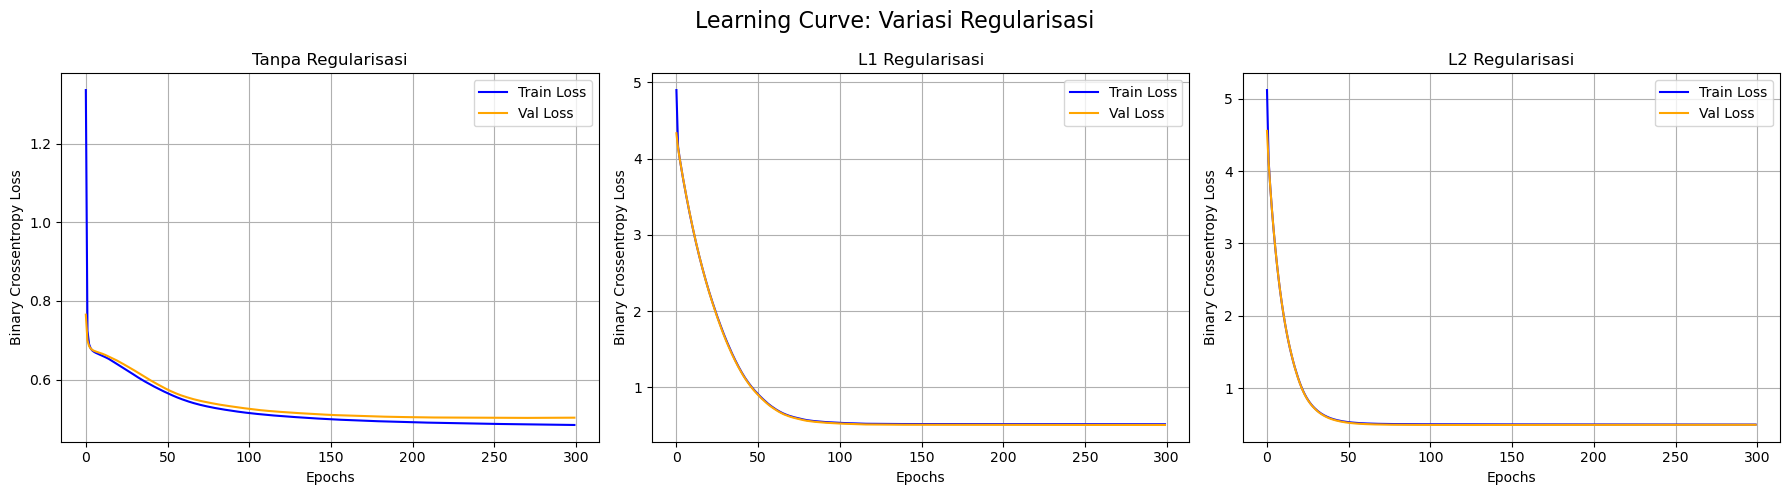

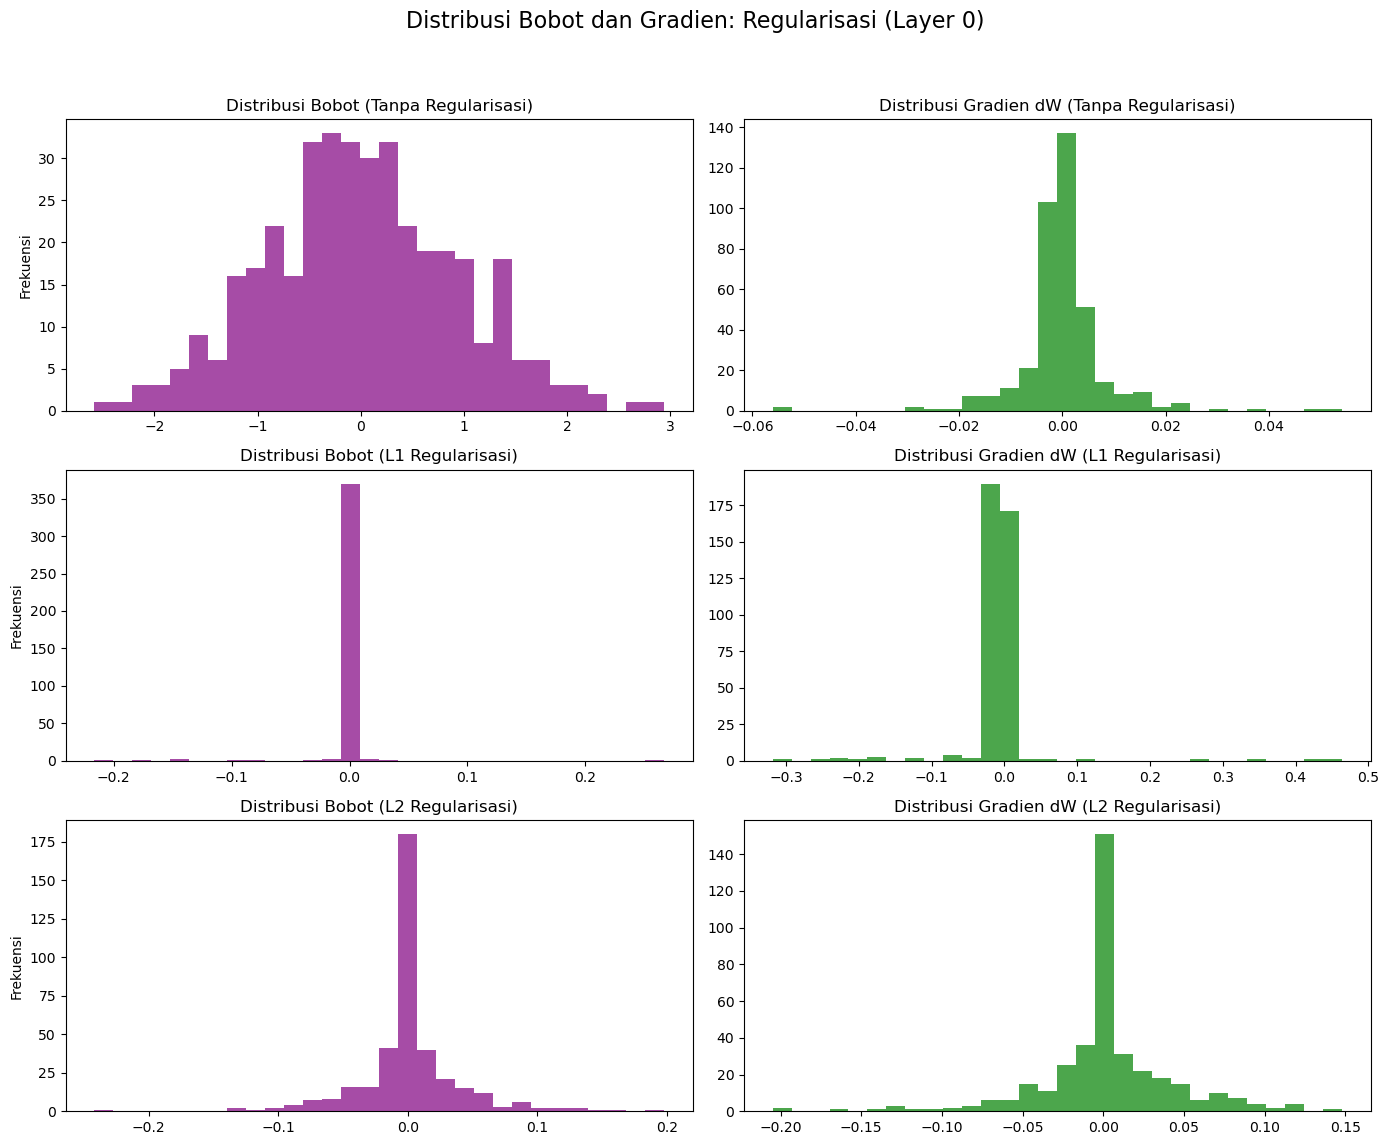

Evaluasi Prediksi : Regularisasi

[Tanpa Regularisasi]:
- Accuracy  : 0.7605
- Precision : 0.7687
- Recall    : 0.8710
- F1-Score  : 0.8167

[L1 Regularisasi]:
- Accuracy  : 0.7620
- Precision : 0.7585
- Recall    : 0.8971
- F1-Score  : 0.8220

[L2 Regularisasi]:
- Accuracy  : 0.7635
- Precision : 0.7629
- Recall    : 0.8906
- F1-Score  : 0.8218


In [16]:
input_dim = X_train_scaled.shape[1]
epochs = 300
batch_size = 32
lr = 0.01
lambda_reg = 0.01
regs = ['Tanpa Regularisasi', 'L1 Regularisasi', 'L2 Regularisasi']
models_dict_reg = {}
histories_reg = {}
predictions_reg = {}

print("Eksperimen Pengaruh Regularisasi")
for reg_type in regs:
    print(f"Training Model: {reg_type}")
    model = Sequential()
    
    if reg_type == 'L1 Regularisasi':
        reg_func = l1(lambda_reg)
    elif reg_type == 'L2 Regularisasi':
        reg_func = l2(lambda_reg)
    else:
        reg_func = None

    model.add(Dense(n_neuron=16, input_dim=input_dim, activation="relu", kernel_regularizer=reg_func, seed=42))
    model.add(Dense(n_neuron=8, activation="relu", kernel_regularizer=reg_func, seed=42))
    model.add(Dense(n_neuron=1, activation="sigmoid", seed=42))
    model.compile(loss="binary_crossentropy")
    
    histories_reg[reg_type] = model.fit(
        x_train=X_train_scaled, 
        y_train=y_train, 
        x_val=X_val_scaled, 
        y_val=y_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        learning_rate=lr, 
        verbose=0
    )
    predictions_reg[reg_type] = (model.predict(X_val_scaled) > 0.5).astype(int).flatten()
    models_dict_reg[reg_type] = model

plot_learning_curves(histories_reg, title="Learning Curve: Variasi Regularisasi", y_label="Binary Crossentropy Loss")
plot_distributions(models_dict_reg, layer_idx=0, title="Distribusi Bobot dan Gradien: Regularisasi (Layer 0)")
evaluate_metrics(predictions_reg, y_val, title="Evaluasi Prediksi : Regularisasi")

## Eksperimen Pengaruh Optimizer Adam

Eksperimen Pengaruh Optimizer Adam
Training Model: Tanpa optimizer (SGD 0.01)
Training Model: Optimizer Adam (Initial Learning Rate = 1e-5)


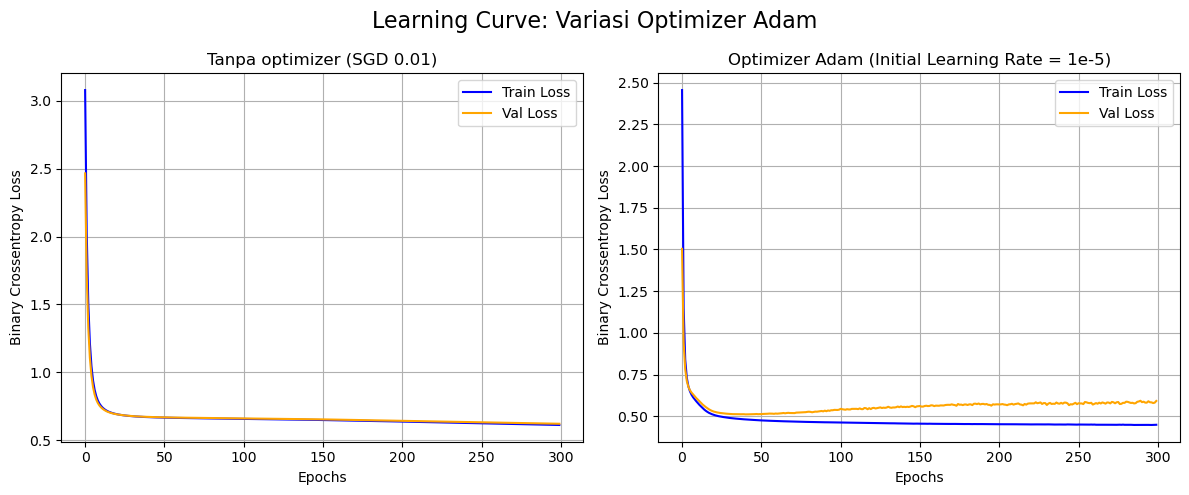

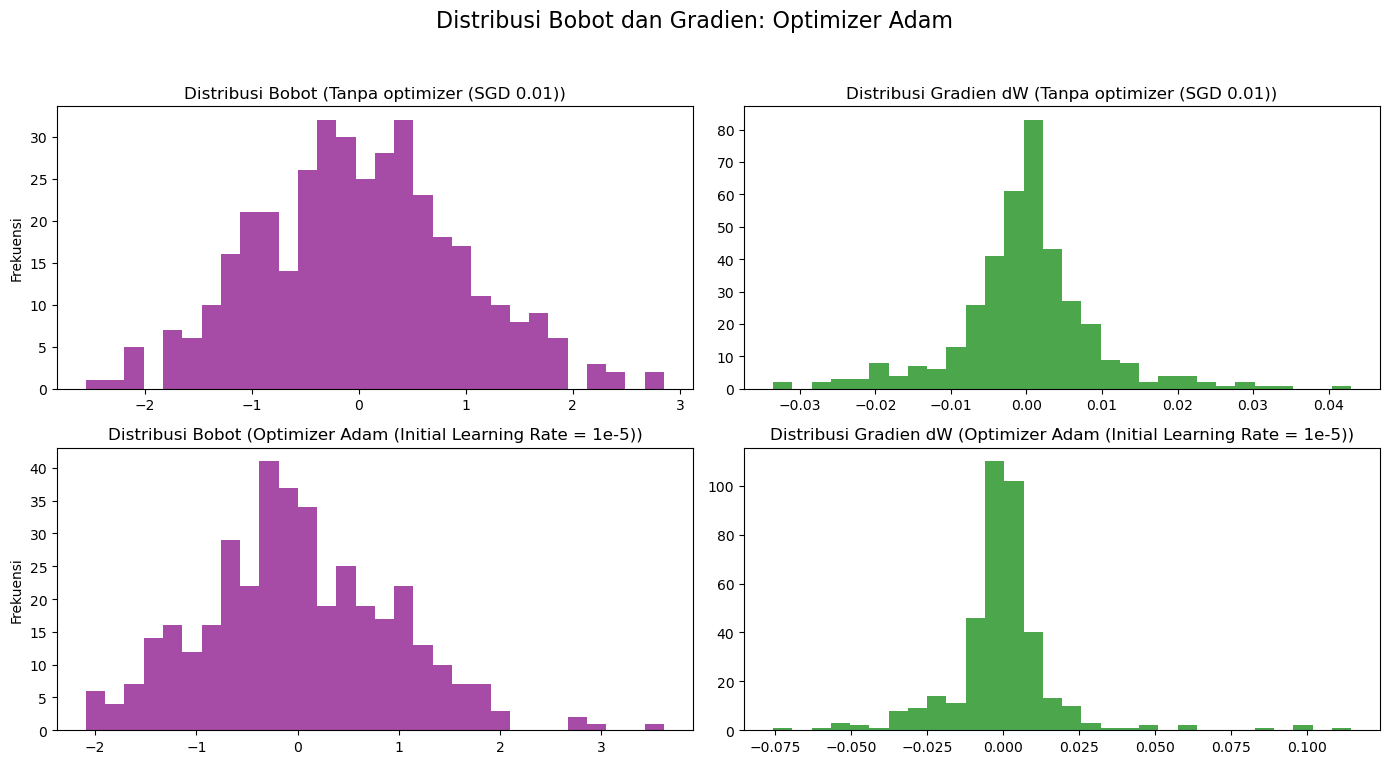

Evaluasi Prediksi : Optimizer Adam

[Tanpa optimizer (SGD 0.01)]:
- Accuracy  : 0.6350
- Precision : 0.6495
- Recall    : 0.8776
- F1-Score  : 0.7465

[Optimizer Adam (Initial Learning Rate = 1e-5)]:
- Accuracy  : 0.7455
- Precision : 0.7668
- Recall    : 0.8400
- F1-Score  : 0.8017


In [17]:
input_dim = X_train_scaled.shape[1]
epochs = 300
batch_size = 32
opt_types = ['Tanpa optimizer (SGD 0.01)', 'Optimizer Adam (Initial Learning Rate = 1e-5)']
models_dict_opt = {}
histories_opt = {}
predictions_opt = {}

print("Eksperimen Pengaruh Optimizer Adam")
for opt_type in opt_types:
    print(f"Training Model: {opt_type}")
    model = Sequential()
    
    if opt_type == 'Optimizer Adam (Initial Learning Rate = 1e-5)':
        opt = Adam(1e-5)
    else:
        opt = SGD(0.01)

    model.add(Dense(n_neuron=16, input_dim=input_dim, activation="relu", seed=42))
    model.add(Dense(n_neuron=8, activation="relu", seed=42))
    model.add(Dense(n_neuron=1, activation="sigmoid", seed=42))
    model.compile(loss="binary_crossentropy", optimizer=opt)
    
    histories_opt[opt_type] = model.fit(
        x_train=X_train_scaled, 
        y_train=y_train, 
        x_val=X_val_scaled, 
        y_val=y_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        verbose=0
    )
    predictions_opt[opt_type] = (model.predict(X_val_scaled) > 0.5).astype(int).flatten()
    models_dict_opt[opt_type] = model

plot_learning_curves(histories_opt, title="Learning Curve: Variasi Optimizer Adam", y_label="Binary Crossentropy Loss")
plot_distributions(models_dict_opt, layer_idx=0, title="Distribusi Bobot dan Gradien: Optimizer Adam")
evaluate_metrics(predictions_opt, y_val, title="Evaluasi Prediksi : Optimizer Adam")

## Eksperimen Pengaruh RMSNormalization

Eksperimen Pengaruh RMSNormalization
Training Model: Tanpa Normalizer
Training Model: RMSNormalization


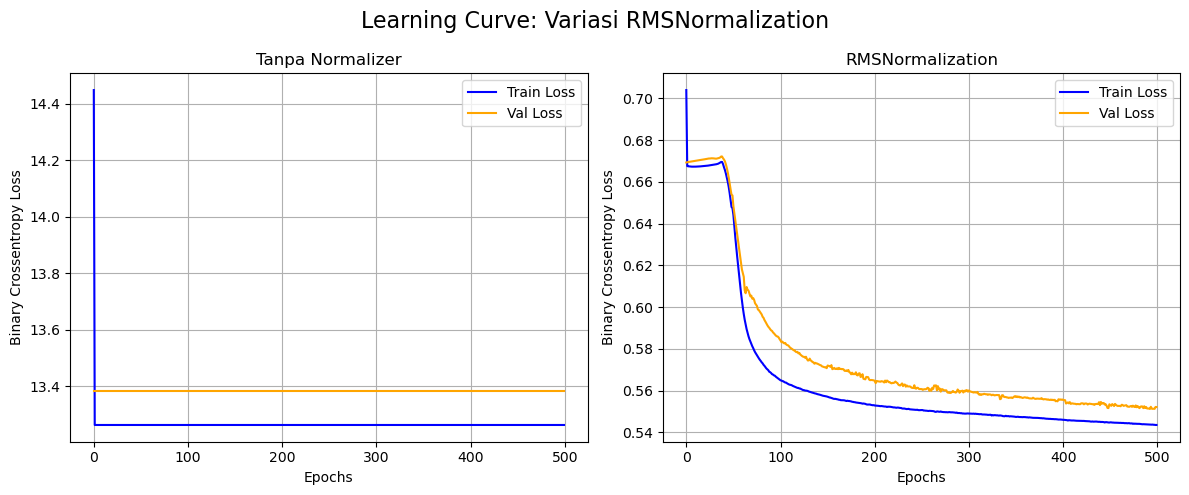

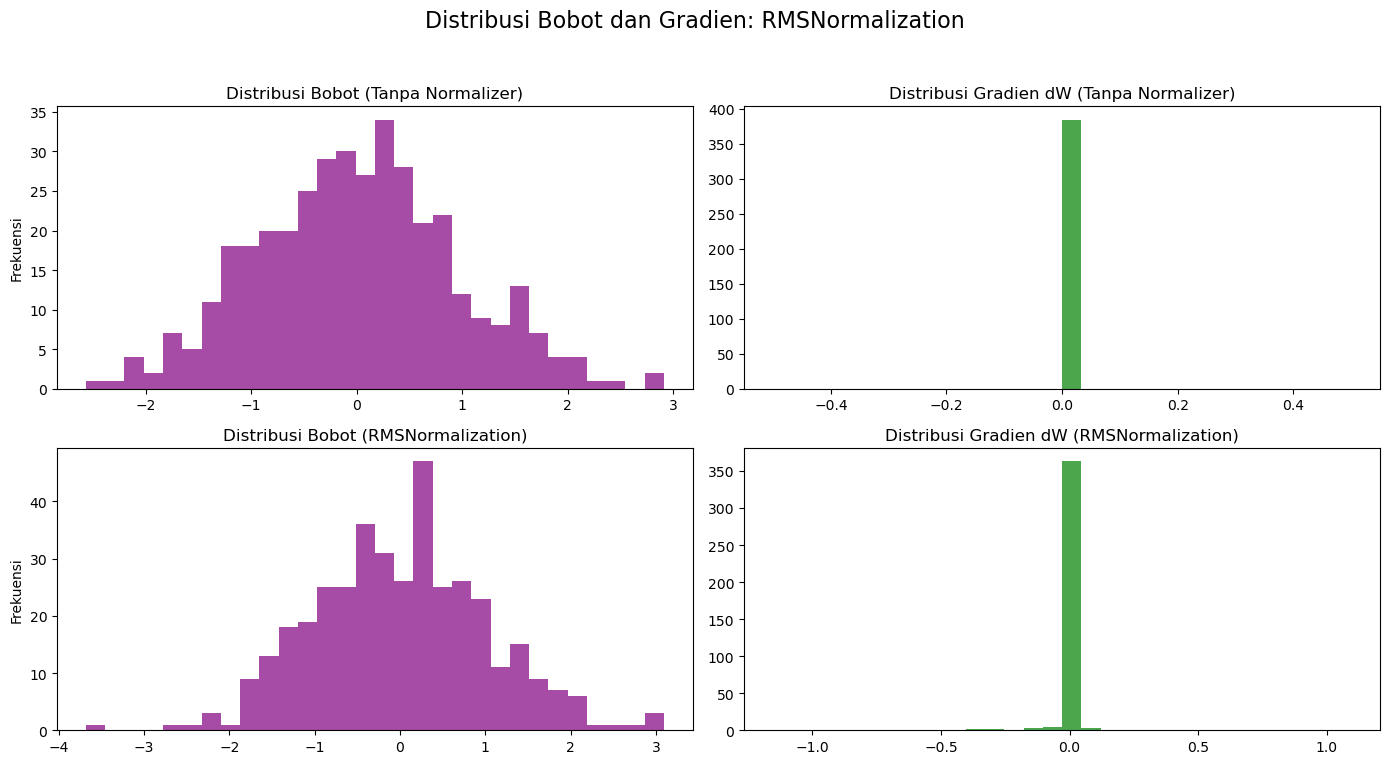

Evaluasi Prediksi : RMSNormalization

[Tanpa Normalizer]:
- Accuracy  : 0.6125
- Precision : 0.6125
- Recall    : 1.0000
- F1-Score  : 0.7597

[RMSNormalization]:
- Accuracy  : 0.7160
- Precision : 0.7002
- Recall    : 0.9380
- F1-Score  : 0.8018


In [18]:
input_dim = X_train.shape[1]
epochs = 500
batch_size = 32
norm = ['Tanpa Normalizer', 'RMSNormalization']
models_dict_norm = {}
histories_norm = {}
predictions_norm = {}

print("Eksperimen Pengaruh RMSNormalization")
for norm_type in norm:
    print(f"Training Model: {norm_type}")
    model = Sequential()

    model.add(Dense(n_neuron=16, input_dim=input_dim, activation="relu", seed=42))
    if norm_type == 'RMSNormalization':
        
        model.add(Dense(n_neuron=8, seed=42))
        model.add(RMSNormalization())
        model.add(Activation('relu'))
    else:
        model.add(Dense(n_neuron=8, activation="relu", seed=42))

    
    model.add(Dense(n_neuron=1, activation="sigmoid", seed=42))
    model.compile(loss="binary_crossentropy")
    
    histories_norm[norm_type] = model.fit(
        x_train=X_train, 
        y_train=y_train, 
        x_val=X_val, 
        y_val=y_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        learning_rate=lr, 
        verbose=0
    )
    predictions_norm[norm_type] = (model.predict(X_val) > 0.5).astype(int).flatten()
    models_dict_norm[norm_type] = model

plot_learning_curves(histories_norm, title="Learning Curve: Variasi RMSNormalization", y_label="Binary Crossentropy Loss")
plot_distributions(models_dict_norm, layer_idx=0, title="Distribusi Bobot dan Gradien: RMSNormalization")
evaluate_metrics(predictions_norm, y_val, title="Evaluasi Prediksi : RMSNormalization")

## Eksperimen Perbandingan dengan Library Sklearn

In [19]:
input_dim = X_train_scaled.shape[1]
epochs = 300
batch_size = 32
lr = 0.01
hidden_layers = (16,8)
predictions_comp = {}

print("Training Model FFNN From Scratch")
model_custom = Sequential()
model_custom.add(Dense(n_neuron=hidden_layers[0], input_dim=input_dim, activation="relu", seed=42))
model_custom.add(Dense(n_neuron=hidden_layers[1], activation="relu", seed=42))
model_custom.add(Dense(n_neuron=1, activation="sigmoid", seed=42))
model_custom.compile(loss="binary_crossentropy")

model_custom.fit(
    x_train=X_train_scaled, 
    y_train=y_train, 
    epochs=epochs, 
    batch_size=batch_size, 
    learning_rate=lr, 
    verbose=0
)
predictions_comp["FFNN From Scratch"] = (model_custom.predict(X_val_scaled) > 0.5).astype(int).flatten()

print("Training Model Sklearn MLPClassifier")
model_sklearn = MLPClassifier(
    hidden_layer_sizes=hidden_layers,
    activation='relu',
    solver='sgd',
    learning_rate_init=lr, 
    learning_rate='constant',
    batch_size=batch_size,
    max_iter=epochs,
    alpha=0.0,
    momentum=0.0,
    random_state=42,
    shuffle=False
)
model_sklearn.fit(X_train_scaled, y_train.flatten())
predictions_comp["Scikit-Learn (MLPClassifier)"] = model_sklearn.predict(X_val_scaled)

evaluate_metrics(predictions_comp, y_val, title="Perbandingan Evaluasi Prediksi")

Training Model FFNN From Scratch
Training Model Sklearn MLPClassifier
Perbandingan Evaluasi Prediksi

[FFNN From Scratch]:
- Accuracy  : 0.7605
- Precision : 0.7687
- Recall    : 0.8710
- F1-Score  : 0.8167

[Scikit-Learn (MLPClassifier)]:
- Accuracy  : 0.7510
- Precision : 0.7695
- Recall    : 0.8473
- F1-Score  : 0.8065


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e78a3996-12a9-4a31-a1e4-a165c9076ec1' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>